In [ ]:
# from utils_ml import *
from codebase.utils_ml import *
# import pandas as pd
import dask.dataframe as dd

from tsfresh import (
    extract_features,  
    select_features
)
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction.settings import from_columns


import matplotlib.gridspec as gridspec

In [ ]:
features_0 = np.array(np.load("../data_8_sim/rawFeatures/ModEsq00.pkl", allow_pickle=True))
features_1 = np.array(np.load("../data_8_sim/rawFeatures/ModEsq01.pkl", allow_pickle=True))
features_2 = np.array(np.load("../data_8_sim/rawFeatures/ModEsq02.pkl", allow_pickle=True))
features_3 = np.array(np.load("../data_8_sim/rawFeatures/ModEsq03.pkl", allow_pickle=True))
features_4 = np.array(np.load("../data_8_sim/rawFeatures/ModEsq04.pkl", allow_pickle=True))
features_5 = np.array(np.load("../data_8_sim/rawFeatures/ModEsq05.pkl", allow_pickle=True))
features_6 = np.array(np.load("../data_8_sim/rawFeatures/ModEsq06.pkl", allow_pickle=True))
features_7 = np.array(np.load("../data_8_sim/rawFeatures/ModEsq07.pkl", allow_pickle=True))

all_features = np.concatenate([features_0, features_1, features_2, features_3, 
                               features_4, features_5, features_6, features_7], axis=0)

label_arr = np.array([np.tile(i,features_0.shape[0]) for i in np.arange(0,8)]).flatten()

features_test = np.array(np.load("rawFeatures/Exp_data_8class.pkl", allow_pickle=True))

# Viz Data Dist sim vs Exp

/tmp/ipykernel_9307/2909322425.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


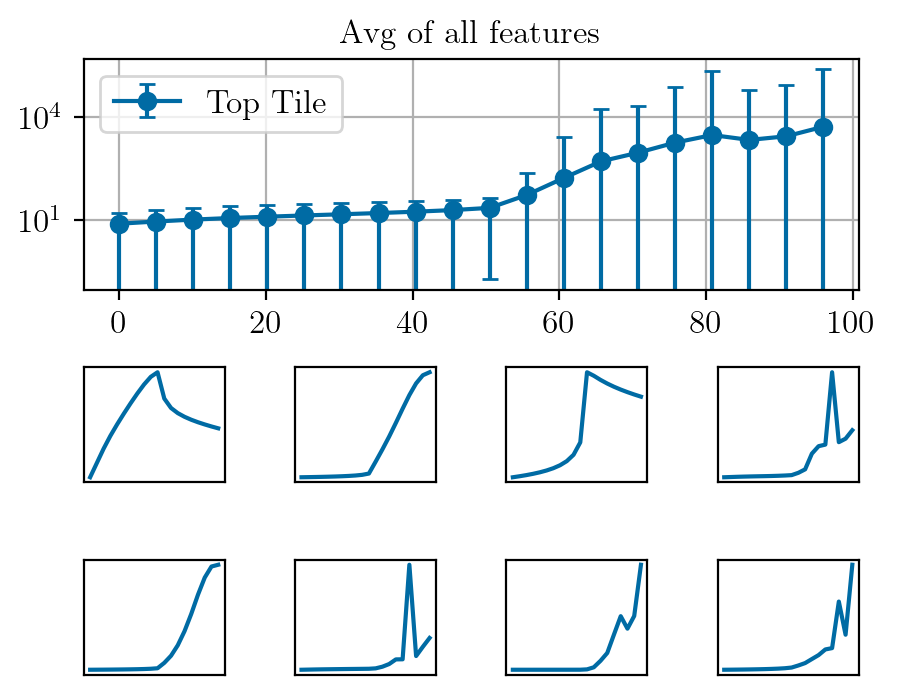

In [45]:
# Generate random data (mean and std)
skip = 5
x = np.linspace(0, 100, 100)[::skip]

fig = plt.figure(figsize=(5, 4))
gs = gridspec.GridSpec(3, 4, height_ratios=[2, 1, 1], hspace=0.5, wspace=0.5)

# Large top subplot
ax0 = plt.subplot(gs[0, :])
ax0.errorbar(x, np.mean(all_features,axis=0)[::skip], yerr=np.std(all_features,axis=0)[::skip], fmt='o-', capsize=3, label="Top Tile")
ax0.set_title("Avg of all features")
ax0.legend()
ax0.grid(True)

ax0.set_yscale("log")

data = [features_0,features_1,features_2,features_3,features_4,features_5,features_6,features_7]

# Middle row (4 tiles)
axes_middle = [plt.subplot(gs[1, i]) for i in range(4)]
for i, ax in enumerate(axes_middle):
    # ax.errorbar(x, np.mean(data[i],axis=0)[::skip], yerr=np.std(data[i],axis=0)[::skip], fmt='s-', capsize=3)
    ax.plot(x, np.mean(data[i],axis=0)[::skip])
    
    # ax.set_title(f"Middle Tile {i+1}")
    ax.grid(True)
    ax.set_yticks([])
    ax.set_xticks([])

# Bottom row (4 tiles)
axes_bottom = [plt.subplot(gs[2, i]) for i in range(4)]
for i, ax in enumerate(axes_bottom):
    # ax.errorbar(x, np.mean(data[i+4],axis=0)[::skip], yerr=np.mean(data[i+4],axis=0)[::skip], fmt='d-', capsize=3)
    ax.plot(x, np.mean(data[i+4],axis=0)[::skip])
    # ax.set_title(f"Bottom Tile {i+1}")
    ax.grid(True)
    ax.set_yticks([])
    ax.set_xticks([])

plt.tight_layout()
plt.show()


# exp dist

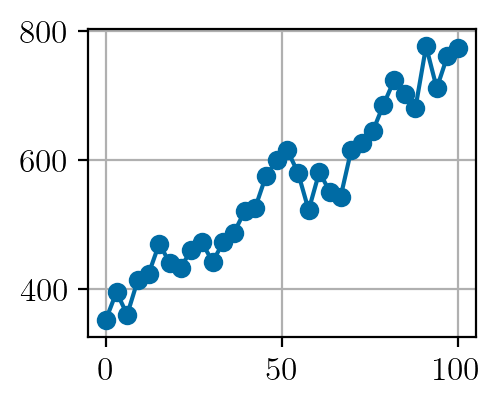

In [ ]:
skip = 3
x = np.linspace(0, 100, 100)[::skip]

fig, ax = plt.subplots(figsize=(2.5, 2))

# Large top subplot
ax.errorbar(x, np.mean(features_test,axis=0)[::skip], yerr=np.std(features_test,axis=0)[::skip], fmt='o-', capsize=3)
ax.grid(True)


# Goal
Extract features from sim data, then extract same features from exp data

In [ ]:
data_df = pd.DataFrame()
labels_df = pd.Series()

data_df['id'] = np.repeat(np.arange(all_features.shape[0]),all_features.shape[1])
data_df['time'] = np.tile(np.arange(all_features.shape[1]), all_features.shape[0])
data_df['feature'] = all_features.flatten()
data_df.to_parquet('rawFeatures/data_df.parquet')

labels_df['labels'] = label_arr

data_df

,id,time,feature
0,0,0,13.753024
1,0,1,14.674004
2,0,2,15.638559
3,0,3,16.635180
4,0,4,17.650384
...,...,...,...
2399995,23999,95,222.277109
2399996,23999,96,237.572621
2399997,23999,97,248.774345
2399998,23999,98,255.216699


In [ ]:
gc.collect()
# Load data once
dask_df = dd.read_parquet('rawFeatures/data_df.parquet')

# Extract features
extracted_features = extract_features(dask_df, column_id="id", column_sort="time",n_jobs=-1, disable_progressbar=False).compute()

# Handle any NaNs
impute(extracted_features)

# Convert labels to a Series (ensure it’s 1D if needed)
labels_series =  pd.Series(np.array(labels_df.to_numpy()[0]))

# Select relevant features
features_filtered = select_features(extracted_features, labels_series, multiclass=True)

# Save to a .npy file with memory-mapping enabled
np.save('features_extracted_8_sim.npy', features_filtered.to_numpy())
gc.collect()

0

In [ ]:
kind_to_fc_parameters = from_columns(features_filtered)

data_exp = pd.DataFrame()


data_exp['id'] = np.repeat(np.arange(features_test.shape[0]),features_test.shape[1])
data_exp['time'] = np.tile(np.arange(features_test.shape[1]), features_test.shape[0])
data_exp['feature'] = features_test.flatten()

data_exp.to_parquet('rawFeatures/data_exp.parquet')

# Load data once
dask_exp = dd.read_parquet('rawFeatures/data_exp.parquet', npartitions=15)

X = extract_features(dask_exp,
                    column_id="id",
                    column_sort="time",
                    pivot=False,
                    kind_to_fc_parameters=kind_to_fc_parameters,
                    disable_progressbar=False
                    )

result = X.compute()

np.save("features_extracted_8_exp.npy", np.reshape(result["value"].to_numpy(), (3000, 530)))

In [5]:
# featurs_exp = np.load("features_exp.npy")
# clf = CatBoostClassifier(
#         verbose=100,  
#         random_state=42         
#         )
    
# clf.fit(features_filtered, label_arr, plot=True)

# pred = clf.predict(featurs_exp)

# fig, ax = plt.subplots(figsize=(1.5,1))
# ax.hist(pred.flatten())